# COGS 108 - EDA Checkpoint

## Authors

- Affaan Hassan: Conceptualization, Writing - original draft, Writing - review & editing, Data curation
- Joey Ye: Writing - original draft, Writing - Review & editing
- Lucy Krych: Analysis, Software, Project administration
- Patricio Ordonez-Acosta: Background research, Writing - original draft
- Minsui Tang: Project administration, Software, Methodology, Exploratory Data Analysis

# Research Question

How do homicide rates in Massachusetts vary by the age group and marital status of the victim, and does this change throughout the year?


## Background and Prior Work

Early criminological work and national surveillance data suggest that homicide is not evenly distributed throughout the year, with many studies reporting higher rates during warmer months. A data collection from the Bureau of Justice Statistics1 found that violent crime tends to increase in the summer, often attributed to greater outdoor activity, increased social interaction, and higher ambient temperatures, which possibly elevates aggression and opportunity for conflict, although the difference is quite small (about 4%).

A closely related project “Crime Seasonality Analysis”2 from GitHub investigates whether crime exhibits predictable seasonal structure by treating crime counts as a time series. The data was sourced from NYC Open Data3 and the City of Chicago data portal4. Methodologically, the project’s pipeline is similar to our project question. The author grouped crime incidents by month and created graphs to see if some months consistently had higher crime than others. Similarly to the data collection from BJS, their result showed that crime is not evenly spread across the year. They also noted that some types of crime show clearer seasonal patterns than others. An important takeaway we noticed was that patterns from New York City and Chicago are not universal — combined data from both cities yielded more ambiguous results than data analyzed separately, which is also a common statistical phenomenon known as Simpson’s Paradox5. From this, we will take into consideration that crime seasonality is fluid and depends on location/time period, rather than following one fixed national pattern, and that any potential pattern we find is likely not permanent. Thus, we will also test whether homicide patterns change over time.

^ Block, Carolyn Rebecca. Seasonality of Crime and Victimization. Bureau of Justice Statistics, U.S. Department of Justice, 2010, https://bjs.ojp.gov/content/pub/pdf/spcvt.pdf
^ Ty1erz. Crime Seasonality Analysis. GitHub, https://github.com/ty1erz/seasonality_and_crime
^ New York City Open Data. NYC Crime Dataset, City of New York, https://data.cityofnewyork.us/Public-Safety/NYC-crime/qb7u-rbmr/about_data
^ City of Chicago Data Portal. Crimes – 2001 to Present, City of Chicago, https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data
^ Blyth, Colin. “Simpson’s Paradox.” Stanford Encyclopedia of Philosophy, Stanford University, https://plato.stanford.edu/entries/paradox-simpson/



# Hypothesis


Null: There is no significant difference in homicide rates across observed groups and any observed variations are due to randomness. Homicide rates are the same throughout the months of the year, and there is no clear trend of homicide rates in different groups of people over time. 

Alternative: Homicide rates vary and change based on age group and marital status of a person, with specific times of the year having different homicide rates.

Our Hypothesis: People that were married are more likely to be victims of homicide, due to unstable partners and relationship issues, and people that are in younger age groups are more likely to be victims of homicide as younger people are more likely to be surrounded by unstable people, whereas older groups are typically in a more stable place with more stable relationships. Homicides will increase during summer, as described in the paper about violent crime in our background section, because we think that people have more free time in the summer which leads to increased homicides.

## Data

### Data overview

Our primary dataset records information on individual births and deaths, with each row representing a single person. Key variables include **date of birth**, **date of death**, **marital status**, and **manner of death**.

For effective analysis, the dataset should:

- Span multiple years, allowing trends over time to be examined.
- Include columns for month and year of death, enabling sorting by month and tracking patterns across years.
- Be geographically diverse, avoiding concentration in a single area.
- Be collected in a random manner to reduce sampling bias.
- Have a large sample size, ensuring results are statistically robust and not overly influenced by chance.

A potential issue with non-random sampling could occur if data were only gathered from a specific, high-end funeral home; this would bias the dataset toward wealthier individuals.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████████         | 1/2 [00:00<00:00,  3.85it/s]

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████████████| 2/2 [00:00<00:00,  4.57it/s]

Successfully downloaded: bad-drivers.csv


### Dataset: Individual-Level Mortality Records with Birthday Proximity (The Pudding “Birthday Effect” Dataset)

https://github.com/the-pudding/data/tree/master/birthday-effect.

This dataset contains approximately 1.96 million individual mortality records across 7 columns, with each row representing a single person’s death. Key variables include date of birth, date of death, marital status, age, sex, place of residence, and manner of death.

Our focuses for analysis are:

- **Manner of death** – to examine homicide rates relative to other causes of death.
- **Marital status and age** – to compare homicide rates across different demographic groups.
- **Date of death** – to identify seasonal patterns and trends over time.

This dataset closely matches our ideal dataset, providing all the desired variables plus additional demographic information and a large sample size. However, a few considerations remain:

- Some entries may have missing or incomplete data for certain variables.
- Although the dataset is extensive, there may be sampling biases related to geographic or demographic coverage.


#### Potential Concerns and Limitations

- **Geographic scope:** The dataset only includes births and deaths in Massachusetts, so any generalizations beyond this state should be made cautiously.
- **Unknown sampling methods:** The methods used to collect the data are not documented. This raises the possibility of sampling bias, similar to the issue noted earlier, where certain demographics may be over- or under-represented.
- **Missing or incomplete data:** Some demographic variables, such as marital status, may have missing values that are not missing at random, and certain age groups or manners of death may be disproportionately affected.
- **Data formatting:** Birth and death dates are stored as strings and will need to be converted to datetime format for accurate analysis.


#### Important Variables and Metrics

* birth (date): The individual’s date of birth. Stored initially as a string but convertible to datetime format.
* death (date): The individual’s date of death.
* age_floor (integer, years): The age at death, rounded down to the nearest whole year. Units are years. Typical human lifespan ranges from 0 to roughly 110–120 years. Values outside this range may indicate data errors.
* days_from_birthday (integer, days): The number of days between the individual’s birthday and their death. Units are days. A value of 0 means the person died on their birthday. Values typically range from -182 to +182 (approximately half a year before or after the birthday), though the dataset contains 365 unique values reflecting all possible calendar-day distances.
* sex (categorical): Biological sex category.
* marital (categorical): Marital status at time of death.
* manner (categorical): Manner of death (e.g., natural, accident, suicide, homicide, etc.).

### Loading Raw Data

In [3]:
import pandas as pd
import numpy as np
import os

os.makedirs("data/00-raw", exist_ok=True)
os.makedirs("data/01-interim", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

url = "https://raw.githubusercontent.com/the-pudding/data/refs/heads/master/birthday-effect/birthdays.csv"
local_path = "data/00-raw/birthdays.csv"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(url)
    df.to_csv(local_path, index = False)

df.head()

,birth,death,age_floor,days_from_birthday,sex,marital,manner
0,1988-11-22,1990-09-26,1,-57,f,s,n
1,1988-02-09,1990-01-07,1,-33,f,s,n
2,1988-04-01,1990-02-13,1,-47,m,s,n
3,1988-04-11,1990-02-24,1,-46,f,s,n
4,1988-08-14,1990-02-27,1,-168,f,s,n


### Tidying Dataset

Not too much to do because the dataset is already tidy; each row represents only one individual record, each column represents one single variable, and each cell contains one value. No further tidying necesary.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 371043 entries, 0 to 371042
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   birth               371043 non-null  str  
 1   death               371043 non-null  str  
 2   age_floor           371043 non-null  int64
 3   days_from_birthday  371043 non-null  int64
 4   sex                 217795 non-null  str  
 5   marital             370434 non-null  str  
 6   manner              361561 non-null  str  
dtypes: int64(2), str(5)
memory usage: 19.8 MB


### Dataset Size

In [5]:
print("Shape:", df.shape)
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Shape: (371043, 7)
Total rows: 371043
Total columns: 7


### Convert Date Columns

Converting date columns from text strings to pandas datetime64[ns] to allow for more operations and calculations to be performed on the data directly from the columns.

In [6]:
df["birth"] = pd.to_datetime(df["birth"], errors="coerce")
df["death"] = pd.to_datetime(df["death"], errors="coerce")

### Check for Missing Data

The dataset contains minimal missing data in most core timing variables (birth, death, age_floor, days_from_birthday). Marital status and manner contain <1% missing values. To determine whether missingness appears systematic, we will compare missing rates across demographic groups.

In [7]:
missing_counts = df.isna().sum()
missing_percent = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
sex,153248,41.301952
manner,9482,2.555499
marital,609,0.164132
birth,1,0.000270
death,0,0.000000
age_floor,0,0.000000
days_from_birthday,0,0.000000


### Comparing Missing Rates

Missingness in the marital variable appears to be extremely low across all manner categories. The variation between groups is minimal, and several categories show no missing values at all. Because the missing rates are both very small and relatively similar across groups, there is no strong evidence that missingness is systematically associated with manner of death. This suggests that missing marital data is likely missing at random rather than structurally biased.

* n = Natural
* a = Accident
* s = Suicide
* h = Homicide
* c = Could not determine
* p = Pending investigation
* t = Therapeutic complication (medical/surgical complication

In [8]:
df["marital_missing"] = df["marital"].isna()

df.groupby("manner")["marital_missing"].mean().sort_values(ascending=False)

manner
n    0.001579
a    0.001352
h    0.001181
s    0.001138
c    0.000000
p    0.000000
t    0.000000
Name: marital_missing, dtype: float64

### Outliers and Suspicious Entries

In [9]:
df["flag_age_outlier"] = (df["age_floor"] < 0) | (df["age_floor"] > 120)
df["flag_days_outlier"] = df["days_from_birthday"].abs() > 366

df[["flag_age_outlier", "flag_days_outlier"]].sum()

flag_age_outlier     0
flag_days_outlier    0
dtype: int64

Nothing suspicious so far.

In [10]:
df["marital"].value_counts()

marital
m    145558
s    136354
d     70520
w     16224
a       995
u       783
Name: count, dtype: int64

Marital Status is made up mostly of Widows which seems a bit strange. According to dataset page, w = Widowed, m = Married, s = Single, and d = Divorced. There is no specification for what u and a are, which is also odd. Subsequently, entries with u and a will be dropped.

### Clean Data

Because our goal analysis requires accurate birth and death timing, rows missing these fields cannot meaningfully contribute to the birthday effect analysis. Therefore, rows missing essential timing variables such as these will be removed.

In [11]:
core_cols = ["birth", "death", "age_floor", "days_from_birthday", "marital"]

df_clean = df.dropna(subset=core_cols)

df_clean = df_clean[
    (df_clean["age_floor"].between(0,120)) &
    (df_clean["days_from_birthday"].abs() <= 366)
]

df_clean = df_clean[df_clean["marital"].isin(["w", "m", "s", "d"])]
df_clean

df_clean.to_csv("data/02-processed/birthdays_processed.csv", index=False)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (371043, 10)
Cleaned shape: (368655, 10)


### Summary of Statistics

#### Age at Death

In [12]:
df_clean["age_floor"].describe()

count    368655.000000
mean         48.099212
std          12.794172
min           1.000000
25%          42.000000
50%          52.000000
75%          58.000000
max          62.000000
Name: age_floor, dtype: float64

Age_floor refers to age at death, with the mean age at death being 75.1 and the median being 79. A higher median indicates a slight left skew, meaning there are younger deaths pulling the mean downward.

The interquartile range spans from 67 years (25th percentile) to 87 years (75th percentile), indicating that the middle 50% of individuals died between ages 67 and 87. This suggests the dataset is heavily concentrated among older adults, which aligns with expected mortality patterns.

The minimum recorded age is 1 year, and the maximum is 114 years, both of which fall within plausible biological limits. There are no obvious extreme outliers (e.g., negative ages or values above 120 after cleaning), suggesting the age variable appears valid and well-behaved.

Overall, the distribution of age at death appears realistic and consistent with known mortality patterns.

#### Amount of Days from Birthday after Death

In [13]:
df_clean["days_from_birthday"].describe()

count    368655.000000
mean         -0.905877
std         105.364885
min        -182.000000
25%         -92.000000
50%          -3.000000
75%          91.000000
max         182.000000
Name: days_from_birthday, dtype: float64

The dataset also contains 1,955,586 valid observations for days_from_birthday. The mean value is approximately 0.063 days, which is extremely close to zero. This suggests that, on average, deaths are distributed symmetrically around birthdays.

The median is exactly 0 days, meaning that half of all deaths occurred within roughly half a year before or after a birthday, centered at zero. The interquartile range extends from -91 days (25th percentile) to +91 days (75th percentile). This is nearly perfectly symmetric, indicating that deaths are roughly evenly distributed within about three months on either side of birthdays.

The minimum value is -182 days, and the maximum is +182 days, representing approximately half a year before or after a birthday.

Because the mean is very close to zero and the distribution is symmetric, there is no immediate evidence from summary statistics alone of strong clustering around birthdays. However, more detailed visualizations such as graphs and plots would be required to detect subtle spikes near day 0.

#### Manner of Death

In [14]:
df_clean["manner"].value_counts()

manner
n    285871
a     49789
s     15741
h      5911
c      1202
p       520
t       202
Name: count, dtype: int64

Manner of death is largely made up of 'n' (natural causes). This means that any birthday effect will be primarily impacted by natural cause deaths.

#### Marital Status

In [15]:
df_clean["marital"].value_counts()

marital
m    145558
s    136353
d     70520
w     16224
Name: count, dtype: int64

Marital Status is still made up mostly of Widows which is weird and worth noting.

### Conclusions

The summary statistics indicate that:

- The dataset is large and robust (~1.96 million records).

- Age at death is concentrated among older adults and appears biologically plausible.

- The days_from_birthday variable is symmetrically distributed around zero, suggesting proper construction.

- Most deaths are due to natural causes, consistent with general mortality patterns.

- There are no obvious extreme outliers or structural anomalies in these core variables after cleaning.

The dataset appears suitable for further analysis of potential clustering of deaths around birthdays.

## Results

### Exploratory Data Analysis

#### Load fully wrangled data from data/02-processed

We load the fully processed dataset from data/02-processed to that our EDA is reproducible without requiring re-running the data download and wrangling steps.

In [16]:
PROCESSED_PATH = "data/02-processed/birthdays_processed.csv"

assert os.path.exists(PROCESSED_PATH), f"Processed file not found at {PROCESSED_PATH}"

df = pd.read_csv(PROCESSED_PATH)

df.head()

,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing,flag_age_outlier,flag_days_outlier
0,1988-11-22,1990-09-26,1,-57,f,s,n,False,False,False
1,1988-02-09,1990-01-07,1,-33,f,s,n,False,False,False
2,1988-04-01,1990-02-13,1,-47,m,s,n,False,False,False
3,1988-04-11,1990-02-24,1,-46,f,s,n,False,False,False
4,1988-08-14,1990-02-27,1,-168,f,s,n,False,False,False


#### Separate Data from Homicide Deaths to Non-homicide Deaths

Here, we filter analyses into different groups: homicide victims vs. other causes of death. We will check for patterns in homicide deaths, and compare them to the group with non-homicide deaths to see if there is a group-wise pattern. The dataset with non-homicide deaths serves as a control group for baseline comparison.

In [17]:
df["manner"].value_counts(dropna=False)

homicide = df[df["manner"] == "h"].copy()
non_homicide = df[df["manner"] != "h"].copy()

# Remove flagged outliers
homicide_clean = homicide[
    (~homicide["flag_age_outlier"]) &
    (~homicide["flag_days_outlier"])
].copy()

non_homicide_clean = non_homicide[
    (~non_homicide["flag_age_outlier"]) &
    (~non_homicide["flag_days_outlier"])
    ].copy()

# Drop columns checking for outlier
homicide_clean = homicide_clean.drop(columns = ["flag_age_outlier", "flag_days_outlier"])
non_homicide_clean = non_homicide_clean.drop(columns = ["flag_age_outlier", "flag_days_outlier"])

print("Homicide Data")
display(homicide_clean.head())
print("Non-homicide Data")
display(non_homicide_clean.head())

Homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing
17,1988-06-09,1990-01-16,1,-144,f,s,h,False
174,1990-09-05,1992-08-08,1,-28,m,s,h,False
183,1990-04-06,1992-01-25,1,-71,m,s,h,False
274,1991-06-17,1993-01-11,1,-157,m,s,h,False
340,1992-11-28,1994-06-01,1,-180,m,s,h,False


Non-homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing
0,1988-11-22,1990-09-26,1,-57,f,s,n,False
1,1988-02-09,1990-01-07,1,-33,f,s,n,False
2,1988-04-01,1990-02-13,1,-47,m,s,n,False
3,1988-04-11,1990-02-24,1,-46,f,s,n,False
4,1988-08-14,1990-02-27,1,-168,f,s,n,False


#### Create variables needed for analysis

To support our exporatory analysis, we derive additional variables from the existing dataset that will help us examine patterns related to our hypotheses.

First, we convert the "death" column to a datetime format so that we can extract time-based features. This allows us to create a death_month variable, which enables us to analyze potential seasonal patterns in homicide deaths. Since our hypothesis suggests that homicide incidents may increase during the summer months due to increased social activity and outdoor interaction, examining deaths by months helps us explore this relationship.

In [18]:
homicide_clean["death"] = pd.to_datetime(homicide_clean["death"], errors="coerce")
homicide_clean["death_month"] = homicide_clean["death"].dt.month

non_homicide_clean["death"] = pd.to_datetime(non_homicide_clean["death"], errors="coerce")
non_homicide_clean["death_month"] = non_homicide_clean["death"].dt.month

print("Updated Homicide Data")
display(homicide_clean.head())
print("Updated Non-homicide Data")
display(non_homicide_clean.head())

Updated Homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing,death_month
17,1988-06-09,1990-01-16,1,-144,f,s,h,False,1
174,1990-09-05,1992-08-08,1,-28,m,s,h,False,8
183,1990-04-06,1992-01-25,1,-71,m,s,h,False,1
274,1991-06-17,1993-01-11,1,-157,m,s,h,False,1
340,1992-11-28,1994-06-01,1,-180,m,s,h,False,6


Updated Non-homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing,death_month
0,1988-11-22,1990-09-26,1,-57,f,s,n,False,9
1,1988-02-09,1990-01-07,1,-33,f,s,n,False,1
2,1988-04-01,1990-02-13,1,-47,m,s,n,False,2
3,1988-04-11,1990-02-24,1,-46,f,s,n,False,2
4,1988-08-14,1990-02-27,1,-168,f,s,n,False,2


Next, we group the "age_floor" variable into broader age categories. Using age groups instead of individual ages helps reduce noise in the data and allows us to more easily compare demographic patterns across age ranges. These age groups will help us investigate whether younger individuals appear more frequently among homicide victims.

In [19]:
bins = [0, 18, 25, 35, 50, 65, 120]
labels = ["0-18", "19-25", "26-35", "36-50", "51-65", "65+"]

homicide_clean["age_group"] = pd.cut(
    homicide_clean["age_floor"],
    bins = bins,
    labels = labels,
    right = False)

non_homicide_clean["age_group"] = pd.cut(
    non_homicide_clean["age_floor"],
    bins = bins,
    labels= labels,
    right = False)

print("Updated Age for Homicide Data")
display(homicide_clean.head())
print("Updated Age for Non-homicide Data")
display(non_homicide_clean.head())

Updated Age for Homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing,death_month,age_group
17,1988-06-09,1990-01-16,1,-144,f,s,h,False,1,0-18
174,1990-09-05,1992-08-08,1,-28,m,s,h,False,8,0-18
183,1990-04-06,1992-01-25,1,-71,m,s,h,False,1,0-18
274,1991-06-17,1993-01-11,1,-157,m,s,h,False,1,0-18
340,1992-11-28,1994-06-01,1,-180,m,s,h,False,6,0-18


Updated Age for Non-homicide Data


,birth,death,age_floor,days_from_birthday,sex,marital,manner,marital_missing,death_month,age_group
0,1988-11-22,1990-09-26,1,-57,f,s,n,False,9,0-18
1,1988-02-09,1990-01-07,1,-33,f,s,n,False,1,0-18
2,1988-04-01,1990-02-13,1,-47,m,s,n,False,2,0-18
3,1988-04-11,1990-02-24,1,-46,f,s,n,False,2,0-18
4,1988-08-14,1990-02-27,1,-168,f,s,n,False,2,0-18


#### EDA Plot 1: Age Distribution by Proportion

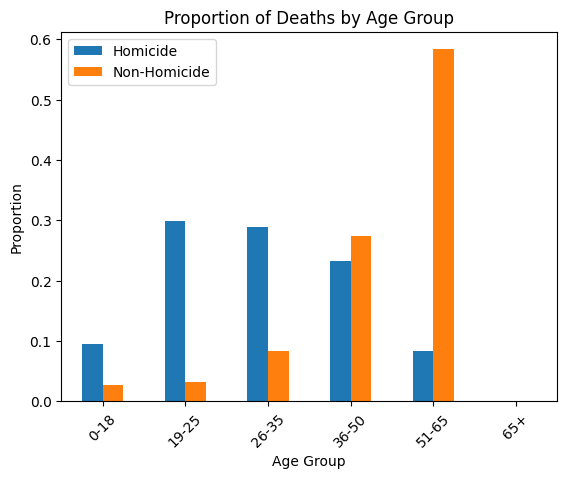

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

age_h_prop = homicide_clean["age_group"].value_counts(normalize=True).sort_index()
age_nh_prop = non_homicide_clean["age_group"].value_counts(normalize=True).sort_index()

age_compare = pd.DataFrame({
    "Homicide": age_h_prop,
    "Non-Homicide": age_nh_prop
})

age_compare.plot(kind="bar")

plt.title("Proportion of Deaths by Age Group")
plt.ylabel("Proportion")
plt.xlabel("Age Group")
plt.xticks(rotation=45)

plt.show()

The distribution of homicide victims in our dataset peaks between ages 19-25. This supports the hypothesis that younger individuals may be more exposed to environments associated with violent crime. 

In comparison, the age distribution for non-homicide deaths peak at 51-65, which is also to be expected, as most non-homicidal deaths are related to old age and declining health issues that follow. 

The age distribution of homicide victims is skewed toward younger age groups compared to non homicide deaths. While non-homicide deaths occur more frequently among older individuals, homicide deaths appear more concentrated among individuals in early adulthood. This suggests that age may play a role in distinguishing homicide deaths from other causes of death, rather than simply reflecting overall mortality patterns. 

#### EDA Plot 2: Sex Distribution by Proportion

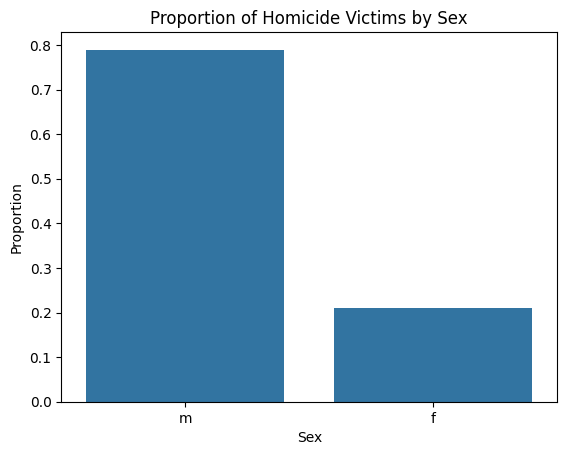

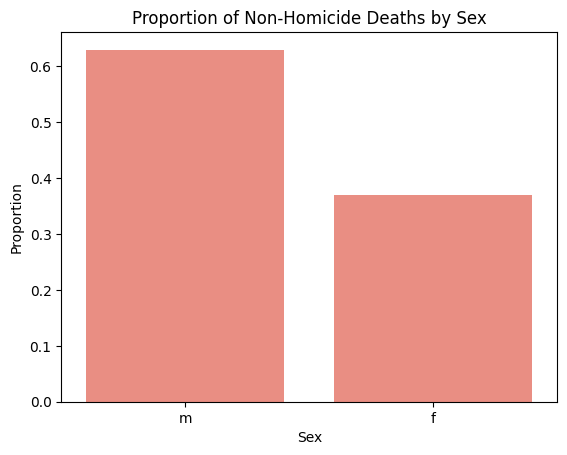

In [21]:
sex_prop_h = (
    homicide_clean["sex"]
    .value_counts(normalize = True)
    .reset_index())

sex_prop_h.columns = ["sex", "proportion"]

sns.barplot(x = "sex", y = "proportion", data = sex_prop_h)

plt.title("Proportion of Homicide Victims by Sex")
plt.ylabel("Proportion")
plt.xlabel("Sex")
plt.show()

# drop the "u" category in non-homicide since there's no data
non_homicide_clean = non_homicide_clean[non_homicide_clean["sex"] != "u"].copy()

sex_prop_nh = (
    non_homicide_clean["sex"]
    .value_counts(normalize = True)
    .reset_index()
)

sex_prop_nh.columns = ["sex", "proportion"]

sns.barplot(x = "sex", y = "proportion", data = sex_prop_nh, color = "salmon")

plt.title("Proportion of Non-Homicide Deaths by Sex")
plt.ylabel("Proportion")
plt.xlabel("Sex")

plt.show()

The first plot shows a strong male skew, which is typical in homicide data. This helps to confirm our data isn't taken from biased samples.

In the second plot, there is also a skew in male. These results suggest that males appear to be disproportionately represented among homicide victims compared to non-homicide deaths, and that the distribution of sex is relatively similar between homicide and non-homicide deaths. The observed male predominance among homicide victims may largely reflect broader mortality patterns rather than being unique to homicide deaths.

#### EDA Plot 3: Marital Status by Proportion

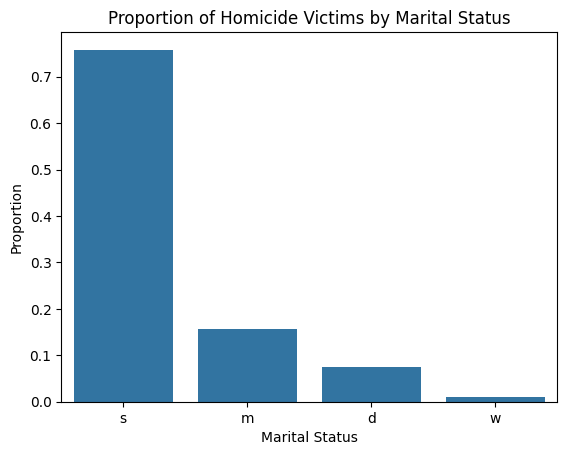

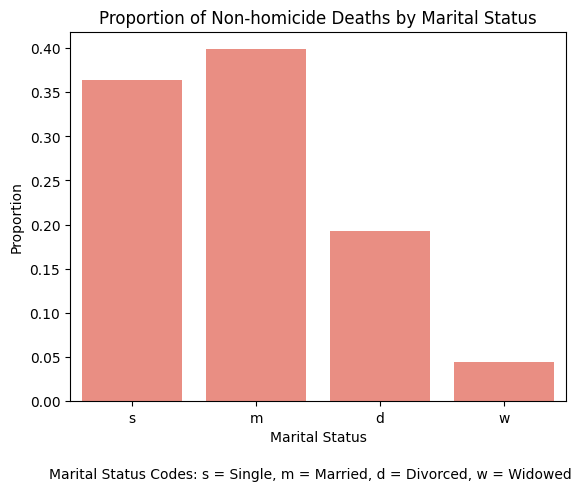

In [22]:
marital_prop_h = (
    homicide_clean["marital"]
    .value_counts(normalize = True)
    .reset_index())

marital_prop_h.columns = ["marital", "proportion"]

order = ["s", "m", "d", "w"]

sns.barplot(x = "marital", y = "proportion", data = marital_prop_h, order = order)

plt.title("Proportion of Homicide Victims by Marital Status")
plt.ylabel("Proportion")
plt.xlabel("Marital Status")
plt.show()

marital_prop_nh = (
    non_homicide_clean["marital"]
    .value_counts(normalize = True)
    .reset_index())

marital_prop_nh.columns = ["marital", "proportion"]

sns.barplot(x = "marital", y = "proportion", data = marital_prop_nh, order = order, color = "salmon")

plt.title("Proportion of Non-homicide Deaths by Marital Status")
plt.ylabel("Proportion")
plt.xlabel("Marital Status")
plt.figtext(
    0.5, -0.05,
    "Marital Status Codes: s = Single, m = Married, d = Divorced, w = Widowed",
    ha="center",
    fontsize=10
)
plt.show()

To determine whether marital status is associated with homicide deaths specifically rather than general mortality patterns, we compared the proportion of marital status categories among homicide victims and non-homicide deaths.

Among non-homicide deaths, the distribution is relatively balanced between married (≈40%) and single (≈36%) individuals, with smaller proportions of divorced (≈19%) and widowed (≈4%) individuals. This distribution likely reflects broader population and mortality trends, where married and older individuals represent a large share of deaths due to natural causes.

In contrast, homicide victims are overwhelmingly single (≈75%). This suggests that single inividuals appear substantially overrepresented among homicide victims relative to other deaths in the dataset. One explanation for this pattern is t hat marital status is strongly associated with age, and homicide deaths in the dataset are more concentrated among younger individuals, who are more likely to be single, compared to married, divorced, and widowed indivudals, who are typically older and therefore more likely to die from natural causes.

The "Widowed" category appears to have very few deaths across both datasets. However, this likely reflects demographic structure rather than a meaningful relationship between widowhood and homicide/death risk. Widowed individuals tend to be older, while homicide victims are disproportionately younger. Additionally, the dataset contains a higher proportion of male victims, while widowed individuals are more frequently female in the general population.

#### EDA Plot 4: Seasonality by Proportion

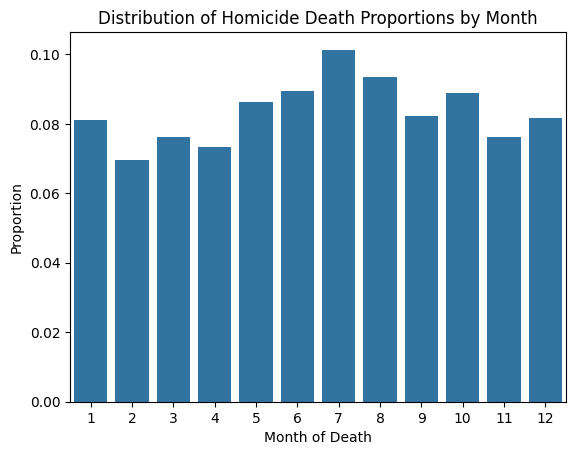

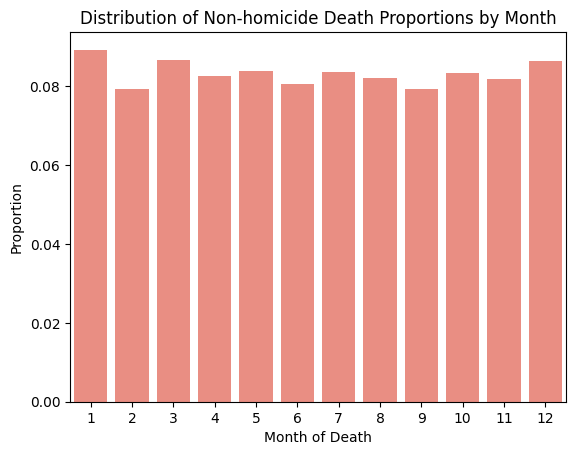

In [23]:
month_prop_h = (
    homicide_clean["death_month"]
    .value_counts(normalize = True)
    .reset_index())

month_prop_h.columns = ["death_month", "proportion"]

sns.barplot(x = "death_month", y = "proportion", data = month_prop_h)
plt.title("Distribution of Homicide Death Proportions by Month")
plt.ylabel("Proportion")
plt.xlabel("Month of Death")
plt.show()

month_prop_nh = (
    non_homicide_clean["death_month"]
    .value_counts(normalize = True)
    .reset_index())

month_prop_nh.columns = ["death_month", "proportion"]

sns.barplot(x = "death_month", y = "proportion", data = month_prop_nh, color = "salmon")
plt.title("Distribution of Non-homicide Death Proportions by Month")
plt.ylabel("Proportion")
plt.xlabel("Month of Death")
plt.show()

The summer months (June - August) show slightly higher counts, which aligns with our previous research suggesting violent crime increases during warmer seasons. In non-homicide deaths, the distribution appears to be spread out pretty even among all months. To see if there is a statistical significance in the "peak" for homicide data, we conduct a Chi-Square test.

In [24]:
# Combine datasets
homicide_clean["death_type"] = "homicide"
non_homicide_clean["death_type"] = "non_homicide"

combined = pd.concat([homicide_clean, non_homicide_clean])

# Create contingency table
month_table = pd.crosstab(combined["death_month"], combined["death_type"])

month_table

death_type,homicide,non_homicide
death_month,,
1,479,32403
2,412,28823
3,450,31429
4,434,29950
5,510,30472
6,529,29264
7,599,30364
8,553,29828
9,487,28809


In [25]:
# Run the Chi-square test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(month_table)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 67.83822125220803
p-value: 3.1403660446963217e-10
Degrees of freedom: 11


Given that the p-value is way below 0.05, we reject the null hypothesis that month of death and death type are independent. This result suggests that homicide deaths exhibit a statistically significant seasonal pattern compared to other causes of death.

#### EDA Plot 5: Birthday Effect

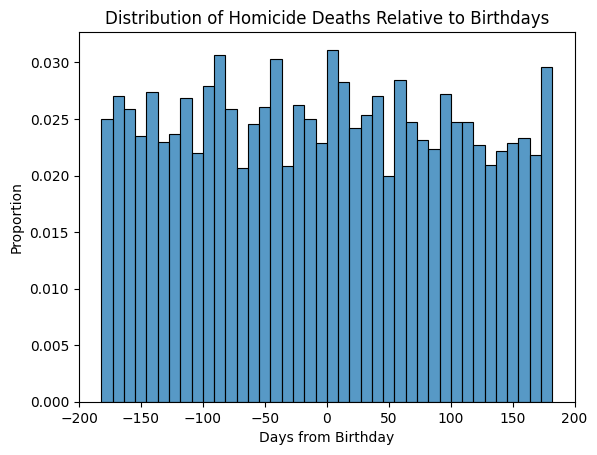

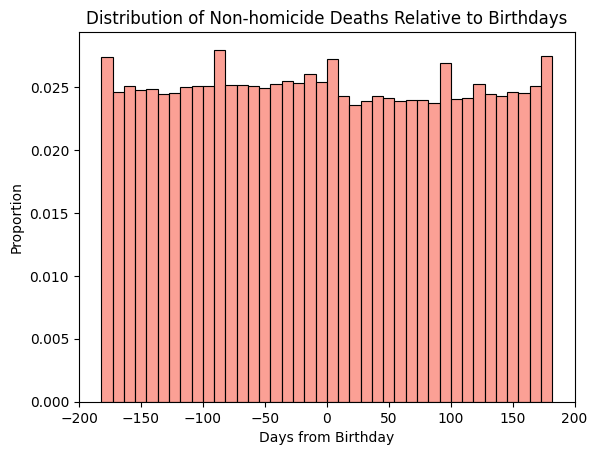

In [26]:
# Homicide deaths
sns.histplot(
    homicide_clean["days_from_birthday"],
    bins = 40,
    stat = "probability"
)

plt.title("Distribution of Homicide Deaths Relative to Birthdays")
plt.xlabel("Days from Birthday")
plt.ylabel("Proportion")
plt.show()


# Non-homicide deaths
sns.histplot(
    non_homicide_clean["days_from_birthday"],
    bins = 40,
    stat = "probability",
    color = "salmon"
)

plt.title("Distribution of Non-homicide Deaths Relative to Birthdays")
plt.xlabel("Days from Birthday")
plt.ylabel("Proportion")
plt.show()

The birthday effect does not appear strongly in this dataset for either homicide nor non-homicide deaths, although there is far more noise in the homicide graph. If it were present during homicide victims, we would expect to see a spike in counts near 0 days. However, the distribution appears relatively uniform across the entire range from roughly -180 to 180 days, with no clear clustering or peak. Overall, the results indicate that the birthday effect, which has been observed in some mortality studies, does not appear to be an influence in homicide deaths in our dataset.

#### EDA Plot 6: Age vs. Marital Status

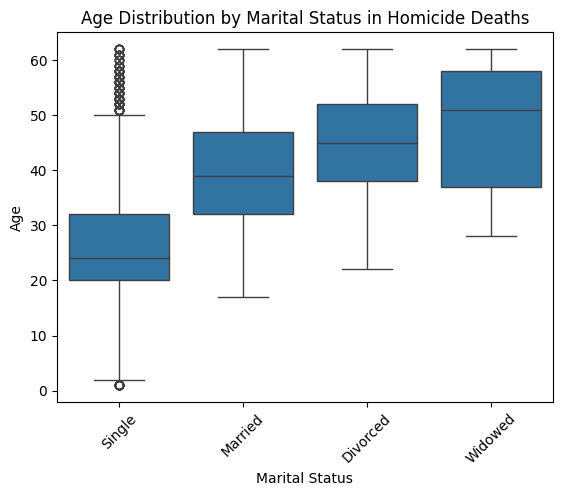

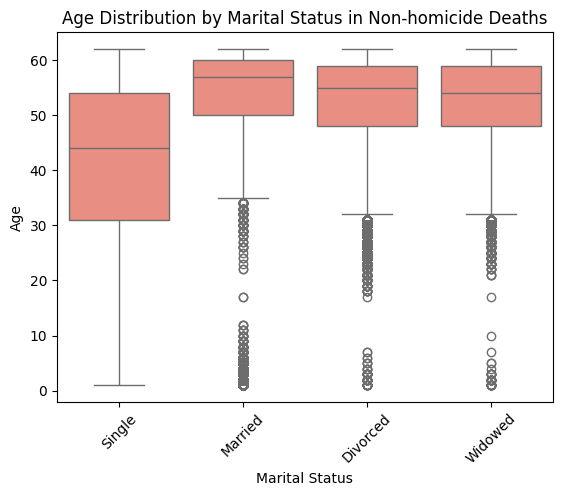

In [27]:
sns.boxplot(x = "marital", y = "age_floor", data = homicide_clean)
plt.xticks(
    rotation = 45,
    ticks = [0, 1, 2, 3],
    labels = ["Single", "Married", "Divorced", "Widowed"])
plt.title("Age Distribution by Marital Status in Homicide Deaths")
plt.ylabel("Age")
plt.xlabel("Marital Status")
plt.show()

sns.boxplot(x = "marital", y = "age_floor", data = non_homicide_clean, color = "salmon")
plt.xticks(
    rotation = 45,
    ticks = [0, 1, 2, 3],
    labels = ["Single", "Married", "Divorced", "Widowed"])
plt.title("Age Distribution by Marital Status in Non-homicide Deaths")
plt.ylabel("Age")
plt.xlabel("Marital Status")
plt.show()

Comparing the two plots suggests that the higher proportion of single individuals among homicide victims is likely driven by the younger age distribution of homicide deaths. Younger individuals are more likely to be unmarried, which explains why the “single” category dominates homicide deaths. Meanwhile, non-homicide deaths occur more frequently among older individuals who are more likely to be married, divorced, or widowed.

These results confirm that age plays a major role in shaping the relationship between marital status and homicide deaths, and the observed differences in marital status between homicide and non-homicide deaths are largely explained by differences in the underlying age distributions, as stated before.

#### EDA Plot 7: Age vs. Sex

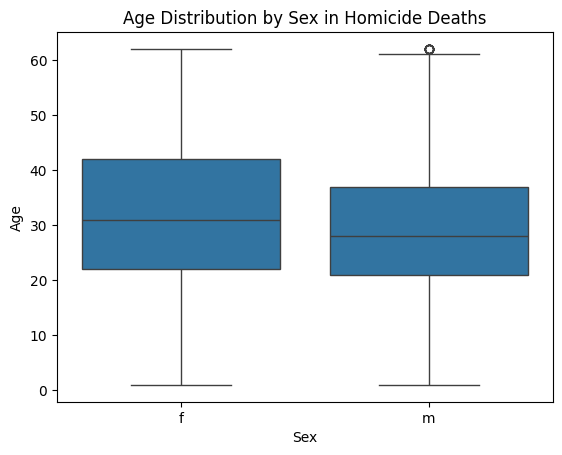

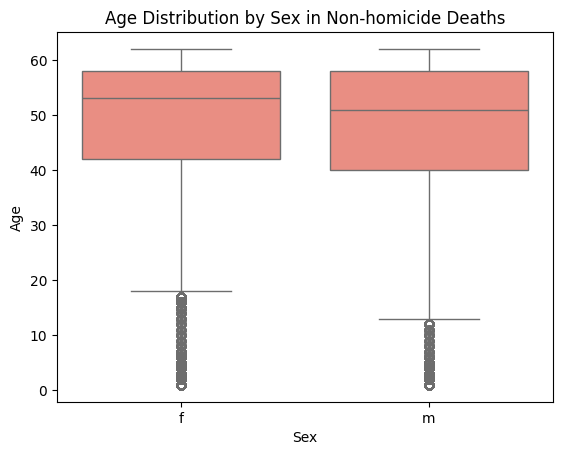

In [28]:
sns.boxplot(x = "sex", y = "age_floor", data = homicide_clean)
plt.title("Age Distribution by Sex in Homicide Deaths")
plt.ylabel("Age")
plt.xlabel("Sex")
plt.show()

sns.boxplot(x = "sex", y = "age_floor", data = non_homicide_clean, color = "salmon")
plt.title("Age Distribution by Sex in Non-homicide Deaths")
plt.ylabel("Age")
plt.xlabel("Sex")
plt.show()

In the non-homicide deaths, both males and females have relatively high median ages, around the early 50s. The distributions are quite similar between sexes, suggesting that age patterns in non-homicide deaths are largely driven by general mortality trends rather than strong differences between males and females. The presence of younger outliers likely reflects rare cases such as childhood illness or accidents, but the majority of deaths occur at older ages.

In contrast, homicide deaths occur at much younger ages for both sexes. The median age for homicide victims is around the late 20s to early 30s, which is substantially lower than the median age observed for non-homicide deaths. This indicates that homicide victims are disproportionately younger compared to individuals who die from other causes.

Additionally, while both sexes show younger age distributions in homicide deaths, the difference between male and female victims appears relatively small. This suggests that the primary demographic difference between homicide and non-homicide deaths is age rather than sex-specific age patterns.

Overall, the comparison highlights a clear demographic distinction: homicide deaths tend to occur among younger individuals, whereas non-homicide deaths are concentrated among older populations. This pattern is consistent with broader criminological findings that violent deaths are more common among younger age groups.

#### Correlation Heatmap

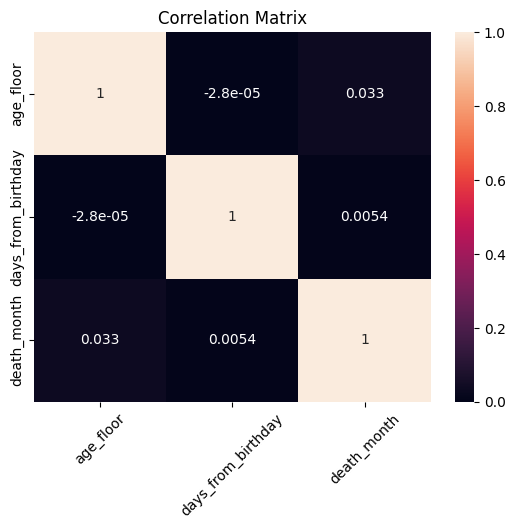

In [29]:
sns.heatmap(homicide_clean.drop(columns = ["marital_missing"]).corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.xticks(rotation = 45)
plt.show()

The correlation matrix shows the pairwise relationships between te numeric variables in the dataset: age_floor, days_from_birthday, and death_month. Correlation values range from -1 to 1, where values closer to +-1 indicate strong relationships and values close to 0 indicate little to no linear relationship. 

In our dataset, the correlations between variables are very small. The weak correlations indicate that the variables capture different aspects of the dataset. This suggests that the timing of homicide deaths relative to birthdays and the month in which deaths occur are largely independent of the victim’s age. 

#### Summary of Key Statistics

In [30]:
combined.groupby(["death_type", "sex"])["age_floor"].describe()

count       mean        std  min   25%   50%   75%   max
death_type   sex                                                             
homicide     f       729.0  32.213992  13.242488  1.0  22.0  31.0  42.0  62.0
             m      2732.0  29.949122  11.747152  1.0  21.0  28.0  37.0  62.0
non_homicide f     78585.0  48.055914  14.142139  1.0  42.0  53.0  58.0  62.0
             m    133801.0  47.767319  12.639105  1.0  40.0  51.0  58.0  62.0

The summary statistics show that, within the deaths recorded in this dataset, homicide victims tend to be younger than non-homicide victims. The mean age for homicide deaths is about 32 years for females and 30 years for males, while non-homicide deaths average around 48 years for both sexes. Median values show the same pattern, with homicide deaths occurring around 28–31 years and non-homicide deaths around 51–53 years.

The interquartile ranges further suggest that homicide deaths in this dataset are concentrated among younger adults, while non-homicide deaths occur more frequently among middle-aged individuals. Male homicide victims also appear slightly younger than female victims, though this difference is small relative to the overall age gap between homicide and non-homicide deaths.

#### EDA Conclusion

The exploratory analysis revealed several patterns in the homicide dataset:

First, homicide deaths in the dataset tend to occur at younger ages compared to non-homicide deaths. This age difference also appears to influence other variables observed in the data.

Second, homicide deaths in the dataset are more frequently male, although the age distributions between males and females are relatively similar within each death category.

Third, marital status distributions differ across death types. Individuals classified as single appear more frequently among homicide deaths, while non-homicide deaths are more commonly associated with married, divorced, or widowed individuals. However, this difference likely reflects the younger age distribution of homicide deaths, since younger individuals are more likely to be unmarried.

Finally, analyses of deaths relative to birthdays do not show a clear visual pattern. While statistical tests indicate differences across months, these results should be interpreted cautiously and only as patterns within the recorded data.

Overall, the EDA suggests that age plays an important role in structuring the patterns observed across homicide and non-homicide deaths in this dataset. These observations describe relationships within the sampled deaths and do not imply causal relationships or predictions about homicide risk in the broader population.

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> The dataset was collected by the Massachusetts Registry of Vital Records and Statistics for administrative purposes and released publicly through a FOIA request. Because this study uses anonymous data with no personally identifiable information, informed consent from individuals was not required for our analysis.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Potential sources of bias include underreporting, differences in the classification of manners of death, and systemic factors that may affect which deaths are recorded as homicides. This dataset also only reflects deaths in Massachusetts, which may not represent other regions. These limits are acknowledged and our conclusions should be restricted to the studied population.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> The dataset contains no PII such as names, addresses, or identification numbers.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> Variables like age, sex, and marital status were used cautiously to check for potential disparities, and not to draw conclusions about any protected group.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> The dataset is public and anonymized on Github, but our analysis on it is accessible only to project members and used solely for academic purposes.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> Our manipulated data will only be retained for the duration of the project. However, the raw dataset is public and controlled by another party.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> The analysis recognizes that homicide rates are influenced by complex social, economic, and environmental factors not expressed in the dataset. Interpretations avoid oversimplification and acknowledge that seasonal variation by itself cannot explain patterns of violence.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Data cleaning steps, including the removal of records with missing info, exclusion of  infant deaths under 1.5 years old, and removal of February 29 entries might introduce bias by omitting certain cases. These decisions were put in place to ensure consistent (month) comparisons and are acknowledged as limitations.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> Only anonymous data is used. No individual cases are to be highlighted, and results should be aggregated.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> All data processing and analysis steps are documented and should be reproducible, allowing for future retesting and correction of potential errors.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> No model is used? The study is descriptive instead of predictive.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> The project communicates that findings show correlation, not causation, and are limited to the Massachusetts dataset and the analyzed timeframe.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> This research is for academic purposes, but it would be interesting to keep monitoring with current data and different locations.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> No decisions affecting individuals were made based on this analysis.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> To reduce risk of unintended use, results are presented carefully while emphasizing that seasonal patterns do not explain underlying causes of homicide and should not be used to support harmful narratives or policies.

## Team Expectations 

* *Each member will contribute to data cleaning, analysis, visualization, coding, and writing.*
* *We expect everyone to communicate clearly and regularly, meet deadlines, and be open to receiving and giving constructive feedback.*
* *Tasks will be divided equally (such as coding, writing, or visualization) to give everyone a fair chance to demonstrate their knowledge and practice their skills in this class.*
* *If someone runs into issues or falls behind, they will let the team know in a timely manner to adjust responsibilities and deadlines.*
* *Any major decisions will be discussed as a group first.*

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/1 | 12 PM | Individual brainstorming on project ideas; look through different data collections; finalize project question | Decide on final dataset; finalize research questions and hypothesis; assign members for project proposal |
| 2/3 | 5 PM |  Project Proposal: Research question (Affaan), data (Affaan), Background & Prior Work (Minsui), Ethics & Privacy (Joey), Hypotheses (Pato), Team Expectations (Minsui), Project Timeline (Minsui)| Review project proposal and format for GitHub submission |
| 2/5 | 5 PM | Review CSV data collection and project proposal (all) | Review data cleaning progress; finalize plan for Checkpoint 1 |
| 2/11 | 5 PM | Start cleaning script for dates and manner of death (Affaan) | Review/Edit wrangling/EDA; Discuss Analysis Plan |
| 2/16 | 12 PM | Data wrangling (Affaan): standardized formats and categories in pandas. EDA & Basic Viz (Minsui) : Generate count plots and other visuals | Polish code/visuals; verify data clarity and readability; submit for Checkpoint 1 |
| 2/25 | 5 PM | Review feedback from Checkpoint 1 and edit sections (all) | Discuss findings and potential confounding variables |
| 3/2 | 12 PM | Cross-variable analysis (Minsui) | Finalize all visualizations; check for code readability|
| 3/4 | 2 PM | Update EDA Checkpoint with Checkpoint 1 work | Submit for Checkpoint 2 |
| 3/11 | 5 PM | Results & Discussion: Draft final project overview explaining data | Review project flow; create presentation; polish final data, project report, and presentation |
| 3/16 | 5 PM | Check for any bugs in repo; finish group peer surveys (everyone) | Ensure all members agree on conclusions; submit final project & group peer surveys |